## Set up data and model objects


In [11]:
%env ENABLE_PJRT_COMPATIBILITY=1

env: ENABLE_PJRT_COMPATIBILITY=1


In [2]:
import pandas as pd
import mudata as md
from perturbo import run_svi, run_mcmc
from perturbo._jax_module import perturbseq_model, perturbseq_guide_autonormal
from perturbo._jax_utils import get_model_args, get_mdata_subset
import seaborn as sns
import matplotlib.pyplot as plt

# gene = "KLF10"
# gene = "PRKCB"
gene = "GATA1"
# gene = "NMU"

/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set training configuration and access to data


### Load the data

(50k cells, takes ~30 seconds)


In [3]:
data_dir = "../../../../Data/gasperini_pilot"

mdata = md.read_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [4]:
def get_targeting_guides(
    mdata,
    gene,
    gene_modality=None,
    guide_modality=None,
    element_target_genes_varm_field=None,
    guide_target_elements_varm_field=None,
):
    element_target_genes_df = mdata[gene_modality].varm[element_target_genes_varm_field].loc[gene]
    # df.loc[:, df.sum() != 0]
    tested_elements = list(element_target_genes_df[element_target_genes_df > 0].index)
    print(tested_elements)
    guide_target_elements_df = mdata[guide_modality].varm[guide_target_elements_varm_field][tested_elements]
    return list(guide_target_elements_df[guide_target_elements_df.sum(axis=1) > 0].index)


guides = get_targeting_guides(
    mdata,
    gene,
    gene_modality="rna",
    guide_modality="grna",
    element_target_genes_varm_field="element_tested",
    guide_target_elements_varm_field="element_targeted",
)
guides
# guides = mdata["grna"].var_names
# guides

['TIMM17B_TSS', 'chrX:48489654-48489677', 'chrX:48641145-48641168', 'chrX:48726316-48726339']


['TIMM17B_TSS|1',
 'TIMM17B_TSS|2',
 'chrX:48489654-48489677|1',
 'chrX:48489654-48489677|2',
 'chrX:48641145-48641168|1',
 'chrX:48641145-48641168|2',
 'chrX:48726316-48726339|1',
 'chrX:48726316-48726339|2']

In [5]:
mdata["rna"].varm["element_tested"].sum(axis=1).sort_values().tail(50)

GPATCH3         15.0
TIMM17A         16.0
KDF1            16.0
RPL12P13        16.0
TRNP1           16.0
SLC9A1          16.0
WDTC1           16.0
ATP6V1C1        16.0
ZNF706          16.0
NACA4P          16.0
PIK3CG          16.0
P4HA1           17.0
CCDC71L         17.0
NUDT13          17.0
ECD             17.0
UBR5            17.0
RRM2B           17.0
NCALD           17.0
FAM149B1        17.0
DNAJC9          17.0
DNAJC9-AS1      17.0
MRPS16          17.0
RNPEP           18.0
LINC02577       18.0
PPP1R12B        18.0
UBE2T           18.0
PTPN7           18.0
ARL8A           18.0
ELF3            18.0
ELF3-AS1        18.0
SLC35F3         18.0
RPL10P4         18.0
KLF10           19.0
GNG4            19.0
AZIN1           20.0
GASAL1          21.0
TOMM20          22.0
RBM34           22.0
ARID4B          22.0
GGPS1           22.0
TBCE            22.0
B3GALNT2        22.0
LINC01132       24.0
COA6            26.0
TARBP1          26.0
IRF2BP2         26.0
COA6-AS1        26.0
U3           

In [6]:
mdata_subset = get_mdata_subset(
    mdata,
    genes=[gene],
    guides=guides,
    rna_modality="rna",
    guide_modality="grna",
    guide_target_elements_varm_field="element_targeted",
    subset_cells=True,
    n_extra_cells=5000,
)
mdata_subset

/Users/ljb80/Projects/perturbo/src/perturbo/_jax_utils.py:127: ImplicitModificationWarning: Setting element `.varm['element_targeted']` of view, initializing view as actual.
  grna_subset.varm[guide_target_elements_varm_field] = grna_by_element.loc[:, grna_by_element.sum() != 0]
Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
2024-04-19 13:40:07.431735: W pjrt_plugin/src/mps_client.cc:563] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!


Metal device set to: Apple M1 Pro

systemMemory: 32.00 GB
maxCacheSize: 10.67 GB



loc("jit(remainder)/jit(main)/ne"(callsite("get_mdata_subset"("/Users/ljb80/Projects/perturbo/src/perturbo/_jax_utils.py":131:0) at callsite("<module>"("/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_36017/3968502307.py":1:0) at callsite("run_code"("/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/IPython/core/interactiveshell.py":3577:0) at callsite("run_ast_nodes"("/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/IPython/core/interactiveshell.py":3517:0) at callsite("run_cell_async"("/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/IPython/core/interactiveshell.py":3334:0) at callsite("_pseudo_sync_runner"("/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/IPython/core/async_helpers.py":129:0) at callsite("_run_cell"("/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/IPython/core/interactiveshell.py":3130:0) at callsite("run_cell"("/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages

MuData object with n_obs × n_vars = 7723 × 9
  2 modalities
    rna:	7723 x 1
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	7723 x 8
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [7]:
# df = mdata_subset["grna"].varm["element_targeted"]
mdata_subset["grna"].X.sum(axis=0)

# mdata_subset["rna"].varm["element_tested"]
# df_subset = df.loc[:, df.sum() != 0]
# df_subset

array([485., 391., 392., 120., 604., 470., 112., 255.], dtype=float32)

In [8]:
perturbseq_guide = perturbseq_guide_autonormal()
model_args, model_kwargs = get_model_args(
    mdata_subset,
    rna_modality="rna",
    guide_modality="grna",
    covariates=["percent_mito", "log_total_guide_count"],
    library_size_column="library_size",
    guide_target_elements_varm_field="element_targeted",
)
for k, v in model_kwargs.items():
    print(k, v.dtype, v.shape)
for v in model_args:
    print(v.dtype, v.shape)

guide_obs bool (7723, 8)
guide_target_elements bool (8, 4)
covariates float32 (7723, 2)
size_factor float32 (7723, 1)
int16 (7723, 1)


<Axes: ylabel='Count'>

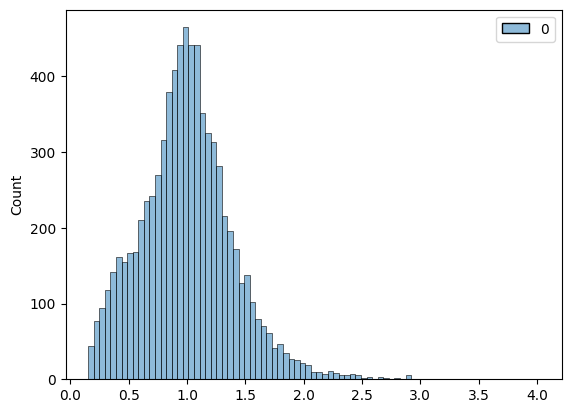

In [9]:
sns.histplot(model_kwargs["size_factor"])

In [10]:
# model_kwargs.update({"subsample_size": 1024})
svi_result = run_svi(
    model_args,
    model_kwargs,
    perturbseq_model,
    perturbseq_guide,
    lr=0.01,
    n_steps=5000,
)

XlaRuntimeError: UNKNOWN: /Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/distributions/discrete.py:184:0: error: failed to legalize operation 'chlo.lgamma'
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/distributions/util.py:675:0: note: called from
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/distributions/distribution.py:655:0: note: called from
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/infer/util.py:85:0: note: called from
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/infer/util.py:292:0: note: called from
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/infer/util.py:410:0: note: called from
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/infer/util.py:426:0: note: called from
/Users/ljb80/.virtualenvs/jax-metal/lib/python3.10/site-packages/numpyro/infer/util.py:440:0: note: called from
/Users/ljb8

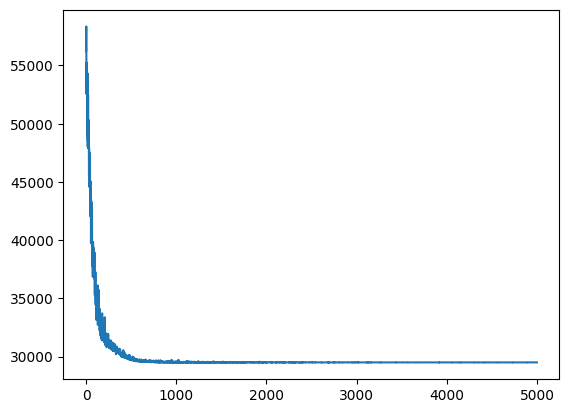

In [ ]:
plt.plot(svi_result.losses)

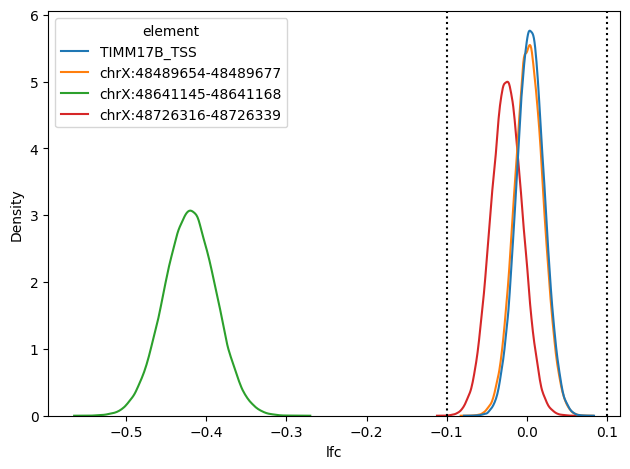

In [ ]:
from jax.random import PRNGKey
from numpyro.infer import Predictive

elements = list(mdata_subset["rna"].varm["element_tested"].columns)
elements = list(mdata_subset["grna"].varm["element_targeted"].columns)

predictive_svi = Predictive(perturbseq_guide, params=svi_result.params, num_samples=100_000)
svi_posterior_samples = predictive_svi(PRNGKey(0), None, **model_kwargs)

lfc_df = pd.DataFrame(svi_posterior_samples["log2_fold_change"][..., 0], columns=elements).melt(
    var_name="element", value_name="lfc"
)

g = sns.kdeplot(lfc_df, x="lfc", hue="element")
plt.axvline(-0.1, color="black", linestyle="dotted")
plt.axvline(0.1, color="black", linestyle="dotted")
plt.tight_layout()
# sns.move_legend(g)

In [ ]:
for k,v in svi_result.params.items():
    print(k, v.shape)

covariate_weights_auto_loc (2, 1)
covariate_weights_auto_scale (2, 1)
dispersion_auto_loc ()
dispersion_auto_scale ()
log2_fold_change_auto_loc (4, 1)
log2_fold_change_auto_scale (4, 1)
mean_auto_loc ()
mean_auto_scale ()


In [ ]:
params = svi_result.params
params

{'covariate_weights_auto_loc': Array([[0.03823862],
        [0.00643241]], dtype=float32),
 'covariate_weights_auto_scale': Array([[0.00885834],
        [0.00834645]], dtype=float32),
 'dispersion_auto_loc': Array(1.9000486, dtype=float32),
 'dispersion_auto_scale': Array(0.05346259, dtype=float32),
 'log2_fold_change_auto_loc': Array([[ 0.00432401],
        [ 0.00218708],
        [-0.42050424],
        [-0.02540127]], dtype=float32),
 'log2_fold_change_auto_scale': Array([[0.01713348],
        [0.01787652],
        [0.03238106],
        [0.01968515]], dtype=float32),
 'mean_auto_loc': Array(1.1898211, dtype=float32),
 'mean_auto_scale': Array(0.01010243, dtype=float32)}

In [ ]:
perturbseq_guide.median(params)

{'mean': Array(3.2864933, dtype=float32),
 'dispersion': Array(6.686219, dtype=float32),
 'log2_fold_change': Array([[ 0.00432401],
        [ 0.00218708],
        [-0.42050424],
        [-0.02540127]], dtype=float32),
 'covariate_weights': Array([[0.03823862],
        [0.00643241]], dtype=float32)}

In [ ]:
unconstrained_locs = {}
for k, v in svi_result.params.items():
    param, param_type = k.split("_auto_")
    if param_type == "loc":
        unconstrained_locs[param] = v
mcmc_model_kwargs = {k: v for k, v in model_kwargs.items() if k != "subsample_size"}
mcmc_result = run_mcmc(model_args, mcmc_model_kwargs, perturbseq_model, unconstrained_locs, num_samples=5000)

sample: 100%|██████████| 6000/6000 [00:45<00:00, 132.33it/s, 7 steps of size 6.26e-01. acc. prob=0.90]


In [ ]:
for k, v in mcmc_result.get_samples().items():
    print(k, v.shape, v.mean(axis=0))

covariate_weights (5000, 2, 1) [[0.02830536]
 [0.0119407 ]]
dispersion (5000,) 6.777979
log2_fold_change (5000, 4, 1) [[ 0.0033621 ]
 [ 0.00505276]
 [-0.42857686]
 [ 0.00118612]]
mean (5000,) 3.275379


In [ ]:
mcmc_posterior_samples = mcmc_result.get_samples()
mcmc_posterior_samples.keys()

dict_keys(['covariate_weights', 'dispersion', 'log2_fold_change', 'mean'])

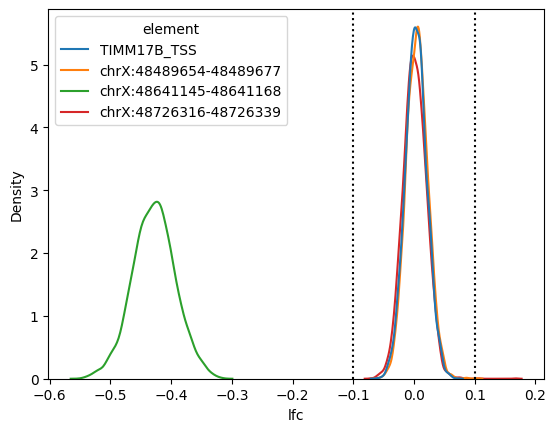

In [ ]:
elements = list(mdata_subset["rna"].varm["element_tested"].columns)
elements = list(mdata_subset["grna"].varm["element_targeted"].columns)


lfc_df = pd.DataFrame(mcmc_posterior_samples["log2_fold_change"][..., 0], columns=elements).melt(
    var_name="element", value_name="lfc"
)

g = sns.kdeplot(lfc_df, x="lfc", hue="element")
plt.axvline(-0.1, color="black", linestyle="dotted")
plt.axvline(0.1, color="black", linestyle="dotted")

# sns.move_legend(g)

In [ ]:
lfc_df.query("abs(lfc)>0.05").value_counts("element")

element
chrX:48641145-48641168    5000
chrX:48726316-48726339      57
chrX:48489654-48489677      37
TIMM17B_TSS                 27
Name: count, dtype: int64

(5000, 2)


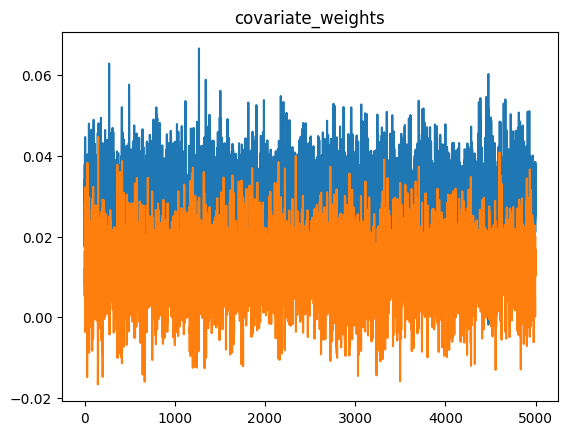

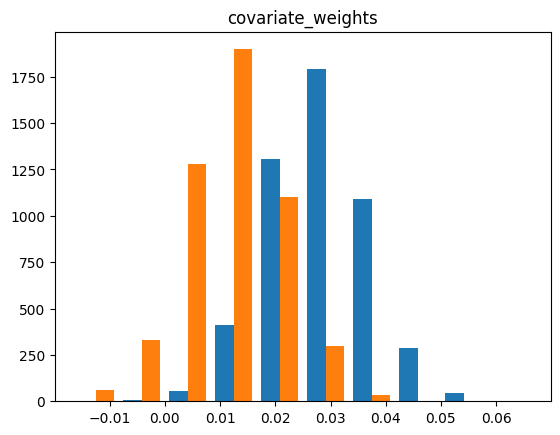

(5000,)


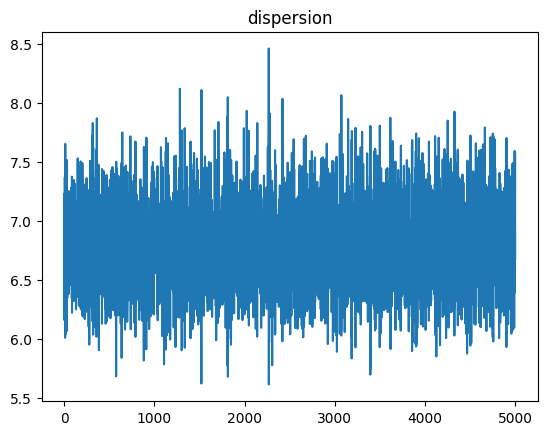

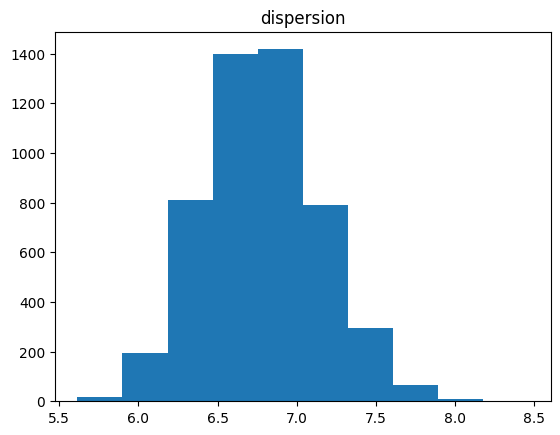

(5000, 4)


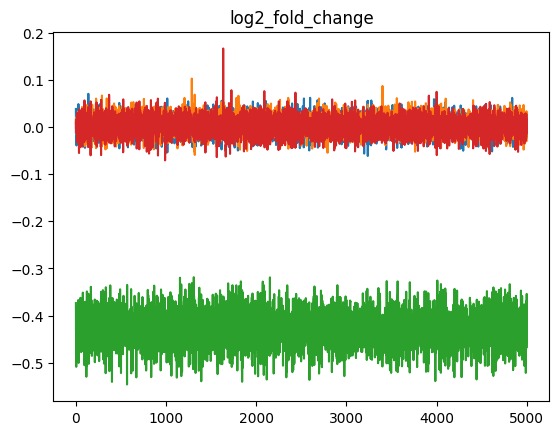

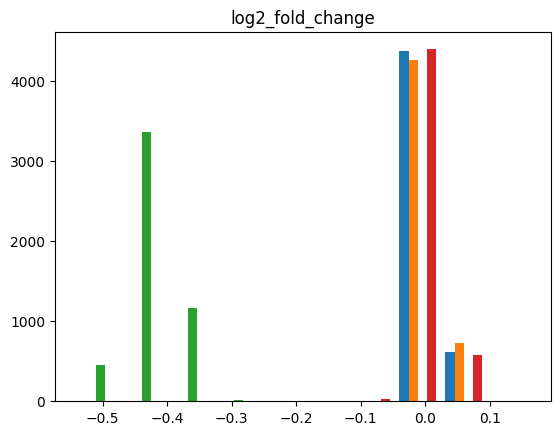

(5000,)


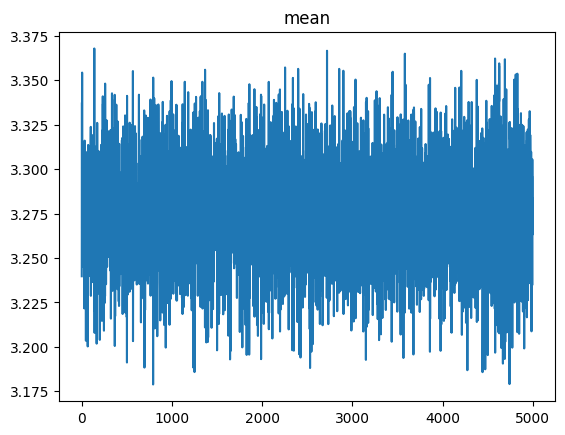

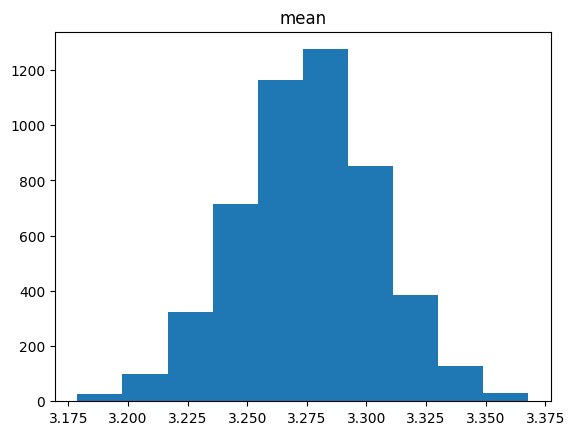

In [ ]:
for k in mcmc_posterior_samples:
    samples_k = mcmc_posterior_samples[k].squeeze()
    print(samples_k.shape)
    if len(samples_k.shape) > 2:
        continue

    plt.plot(samples_k)
    plt.title(k)
    plt.show()

    if len(samples_k.shape) == 2 and samples_k.shape[0] > 1:
        samples_k = samples_k.T

    plt.hist(samples_k)
    plt.title(k)
    plt.show()